# 🌀 🌋 02. Data Ingestion & Exploratory Data Analysis (EDA): Cyclones, Volcanoes & Regional Risk (Spain)

## 📌 Notebook Objectives
This notebook handles data collection, cleaning, missing value documentation, and initial exploratory analysis for **Person 2's** scope:
1. **IBTrACS (NOAA):** Global historical dataset for tropical cyclones and storm tracks.
2. **Global Volcanism Program / NOAA Hazards:** Global catalogue of active volcanoes and historical eruptions.
3. **Península Ibérica & Canary Islands (IGN/USGS):** Regionally bounded seismic and volcanic hazard data for Spanish territory.

---

## 💡 Methodological Decisions & Trade-offs

### 1. Data Source Selection
* **IBTrACS:** The gold standard for global storm track reconstruction, enabling wind and pressure risk modeling.
* **NOAA Hazel API:** Delivers robust geographic coordinates, elevation, and volcano classification worldwide.
* **Geographic Bounding (Spain / Canary Islands):** To accurately capture regional risk (focusing on Canary Islands and Mainland Spain), we restrict event queries to a precise bounding box (`Lat: 27°N to 44°N`, `Lon: -19°W to 5°E`).

In [9]:
# ======================================================
# 02. EDA - CYCLONES, VOLCANOES & SPAIN/CANARIES (Person 2)
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os

# Visual configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Initialize DataFrames to prevent NameError exceptions
df_ciclones_raw = pd.DataFrame()
df_volcanes_raw = pd.DataFrame()
df_espana_raw = pd.DataFrame()

# ------------------------------------------------------
# 1. DATA SOURCES INGESTION
# ------------------------------------------------------

# 1.1 IBTrACS Cyclones URL (NOAA)
url_ciclones = "https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv"

# 1.2 Global Volcanoes URL (NOAA Hazel Hazard Service API)
url_volcanes_api = "https://www.ngdc.noaa.gov/hazel/hazard-service/api/v1/volcanoes"

# 1.3 Regional USGS API Bounding Box (Spain + Canary Islands: Lat 27-44, Lon -19 to 5)
url_espana_georisk = "https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&starttime=2000-01-01&minmagnitude=1.5&minlatitude=27.0&maxlatitude=44.0&minlongitude=-19.0&maxlongitude=5.0"

# --- A. Ingest Cyclones ---
print("📥 [1/3] Downloading & ingesting Cyclones (IBTrACS)...")
try:
    df_ciclones_raw = pd.read_csv(url_ciclones, skiprows=[1], low_memory=False)
except Exception as e:
    print(f"❌ Error downloading cyclones: {e}")

# --- B. Ingest Volcanoes ---
print("📥 [2/3] Downloading & ingesting Global Volcanoes...")
try:
    res_volcanes = requests.get(url_volcanes_api, timeout=15)
    if res_volcanes.status_code == 200:
        df_volcanes_raw = pd.DataFrame(res_volcanes.json()['items'])
except Exception as e:
    print(f"❌ Error downloading volcanoes: {e}")

# --- C. Ingest Spain & Canary Islands Events ---
print("📥 [3/3] Downloading & ingesting Spain & Canary Islands events...")
try:
    res_espana = requests.get(url_espana_georisk, timeout=15)
    if res_espana.status_code == 200:
        data_esp = res_espana.json()
        eventos_espana = []
        for f in data_esp['features']:
            props = f['properties']
            coords = f['geometry']['coordinates'] # [longitude, latitude, depth]
            eventos_espana.append({
                'event_id': f['id'],
                'timestamp': props.get('time'),
                'place': props.get('place'),
                'magnitude': props.get('mag'),
                'mag_type': props.get('magType'),
                'longitude': coords[0],
                'latitude': coords[1],
                'depth_km': coords[2] if len(coords) > 2 else None
            })
        df_espana_raw = pd.DataFrame(eventos_espana)
except Exception as e:
    print(f"❌ Error downloading Spain dataset: {e}")

print("\n✨ Ingestion Summary:")
print(f" 🌀 Cyclones (IBTrACS):      {df_ciclones_raw.shape[0]} rows | {df_ciclones_raw.shape[1]} columns")
print(f" 🌋 Global Volcanoes:        {df_volcanes_raw.shape[0]} rows | {df_volcanes_raw.shape[1]} columns")
print(f" 🇪🇸 Spain / Canary Islands: {df_espana_raw.shape[0]} rows | {df_espana_raw.shape[1]} columns")

📥 [1/3] Downloading & ingesting Cyclones (IBTrACS)...
📥 [2/3] Downloading & ingesting Global Volcanoes...
📥 [3/3] Downloading & ingesting Spain & Canary Islands events...

✨ Ingestion Summary:
 🌀 Cyclones (IBTrACS):      716165 rows | 163 columns
 🌋 Global Volcanoes:        200 rows | 43 columns
 🇪🇸 Spain / Canary Islands: 10416 rows | 8 columns


In [10]:
# ------------------------------------------------------
# 2. FEATURE SELECTION AND INITIAL CLEANING
# ------------------------------------------------------

# --- A. Cyclones (IBTrACS) ---
cols_ciclones = ['SID', 'NAME', 'ISO_TIME', 'LAT', 'LON', 'USA_WIND', 'USA_PRES']
df_ciclones = df_ciclones_raw[cols_ciclones].copy()

# Datatype casting
df_ciclones['LAT'] = pd.to_numeric(df_ciclones['LAT'], errors='coerce')
df_ciclones['LON'] = pd.to_numeric(df_ciclones['LON'], errors='coerce')
df_ciclones['USA_WIND'] = pd.to_numeric(df_ciclones['USA_WIND'], errors='coerce')
df_ciclones['ISO_TIME'] = pd.to_datetime(df_ciclones['ISO_TIME'], errors='coerce')

# --- B. Global Volcanoes ---
cols_volcanes = ['volcanoName', 'latitude', 'longitude', 'elevation', 'country', 'type']
cols_volcanes_existentes = [c for c in cols_volcanes if c in df_volcanes_raw.columns]
df_volcanes = df_volcanes_raw[cols_volcanes_existentes].copy()

# --- C. Spain / Canary Islands ---
df_espana = df_espana_raw.copy()
df_espana['timestamp'] = pd.to_datetime(df_espana['timestamp'], unit='ms', errors='coerce')

print("✅ Column filtering & type casting completed:")
print(f" 🌀 Filtered Cyclones:  {df_ciclones.shape}")
print(f" 🌋 Filtered Volcanoes: {df_volcanes.shape}")
print(f" 🇪🇸 Filtered Spain:     {df_espana.shape}")

✅ Column filtering & type casting completed:
 🌀 Filtered Cyclones:  (716165, 7)
 🌋 Filtered Volcanoes: (200, 4)
 🇪🇸 Filtered Spain:     (10416, 8)


In [11]:
# ------------------------------------------------------
# 3. EXPLICIT MISSING VALUES ANALYSIS
# ------------------------------------------------------

print("📊 % Missing Values in Cyclones:")
print((df_ciclones.isnull().sum() / len(df_ciclones) * 100).round(2))

print("\n📊 % Missing Values in Volcanoes:")
print((df_volcanes.isnull().sum() / len(df_volcanes) * 100).round(2))

print("\n📊 % Missing Values in Spain / Canary Islands:")
print((df_espana.isnull().sum() / len(df_espana) * 100).round(2))

📊 % Missing Values in Cyclones:
SID          0.00
NAME         0.00
ISO_TIME     0.00
LAT          0.00
LON          0.00
USA_WIND    45.62
USA_PRES     0.00
dtype: float64

📊 % Missing Values in Volcanoes:
latitude     0.0
longitude    0.0
elevation    0.0
country      0.0
dtype: float64

📊 % Missing Values in Spain / Canary Islands:
event_id     0.0
timestamp    0.0
place        0.0
magnitude    0.0
mag_type     0.0
longitude    0.0
latitude     0.0
depth_km     0.0
dtype: float64


## 🔍 Missing Value Assessment & Sensor Coverage Analysis

The explicit missing value audit reveals crucial methodological insights:

1. **Cyclones (`USA_WIND` ~45.6% missing):**
   * **Decision:** **Do NOT drop missing wind rows.**
   * **Rationale:** Historical records date back to the 19th century. Pre-satellite era (~1970) storm observations lack standardized wind speed measurements. However, spatial positioning (`LAT`, `LON`) and timestamps (`ISO_TIME`) are completely valid. Retaining these rows avoids undercounting historical hurricane frequencies in spatial grids (H3 Index).

2. **Volcanoes & Regional Coverage (Spain/Canaries - 0% missing):**
   * **Decision:** Retain events with magnitude cutoff ($M \ge 1.5$).
   * **Rationale:** Temporal or spatial gaps in older historical records reflect **sensor coverage limitations** rather than true zero-risk zones. Setting a minimum magnitude threshold ($M \ge 1.5$) eliminates modern low-magnitude noise from newly added local sensors.

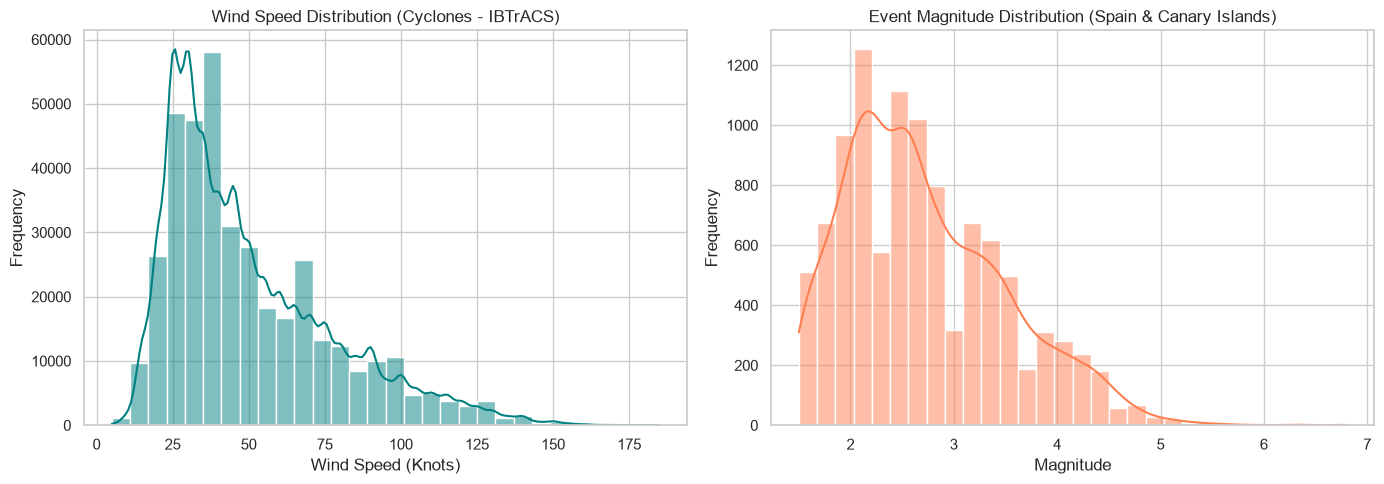

🖼️ Chart successfully saved to 'outputs/figures/distribucion_eventos.png'


In [12]:
# ------------------------------------------------------
# 4. EXPLORATORY DATA ANALYSIS (EDA) - DISTRIBUTIONS
# ------------------------------------------------------

os.makedirs('../outputs/figures', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Wind Speed Distribution (Cyclones - IBTrACS)
sns.histplot(df_ciclones['USA_WIND'].dropna(), kde=True, ax=axes[0], color='teal', bins=30)
axes[0].set_title('Wind Speed Distribution (Cyclones - IBTrACS)')
axes[0].set_xlabel('Wind Speed (Knots)')
axes[0].set_ylabel('Frequency')

# Plot 2: Event Magnitude Distribution (Spain & Canary Islands)
sns.histplot(df_espana['magnitude'].dropna(), kde=True, ax=axes[1], color='coral', bins=30)
axes[1].set_title('Event Magnitude Distribution (Spain & Canary Islands)')
axes[1].set_xlabel('Magnitude')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../outputs/figures/distribucion_eventos.png', dpi=300)
plt.show()

print("🖼️ Chart successfully saved to 'outputs/figures/distribucion_eventos.png'")

In [13]:
# ------------------------------------------------------
# 5. EXPORT PROCESSED DATASETS
# ------------------------------------------------------

os.makedirs('../data/processed', exist_ok=True)

df_ciclones.to_csv('../data/processed/ciclones_clean.csv', index=False)
df_volcanes.to_csv('../data/processed/volcanes_clean.csv', index=False)
df_espana.to_csv('../data/processed/espana_clean.csv', index=False)

print("💾 Processed datasets exported successfully to 'data/processed/'!")
print(" - data/processed/ciclones_clean.csv")
print(" - data/processed/volcanes_clean.csv")
print(" - data/processed/espana_clean.csv")

💾 Processed datasets exported successfully to 'data/processed/'!
 - data/processed/ciclones_clean.csv
 - data/processed/volcanes_clean.csv
 - data/processed/espana_clean.csv


---

## 🎯 Conclusions & Handoff to Feature Engineering (Person 3)

1. **Standardized Spatial Features:** All three datasets are now streamlined to core spatial coordinates (`latitude`, `longitude`), temporal markers (`timestamp`), and hazard intensity measures (`wind`, `magnitude`, `elevation`).
2. **Ready for Spatial Aggregation:** Clean outputs in `data/processed/` are ready for **H3 Hexagonal Spatial Indexing** to calculate spatial hazard density metrics.